# Assignment 4: Leland's modified volatility for hedging under Proportional Transaction Costs

## 1. Assignment Overview
This notebook investigates the impact of proportional transaction costs on discrete delta hedging and implements a modification proposed by Leland (1985). Standard Black-Scholes delta hedging assumes continuous rebalancing and zero trading costs. However, in practice, frequent rebalancing leads to prohibitive transaction costs that can outstrip the value of the option itself. We will empirically compare a naive discrete hedging strategy against Leland's modified approach to evaluate the trade-off between hedging risk (Standard Deviation of P&L) and hedging cost (Expected Mean of P&L).

## 2. Mathematical Framework

### 2.1 The Underlying Asset and Naive Hedging
We assume the underlying asset follows Geometric Brownian Motion (GBM):
$$dS_t = \mu S_t dt + \sigma S_t dW_t$$
where $\sigma$ is the true underlying volatility.

In a discrete hedging framework over $M$ periods with time step $\Delta t = T/M$, the bank adjusts its stock position to match the Black-Scholes Delta ($\Delta$). If a proportional transaction cost rate $k$ is introduced, the cash required to rebalance the portfolio at time $t$ incurs a trading fee:
$$\text{Transaction Cost}_t = k S_t |\Delta_{t} - \Delta_{t-\Delta t}|$$

Under naive hedging, the bank simply uses the true volatility $\sigma$ to calculate $\Delta$. While increasing the rebalancing frequency $M$ theoretically reduces the variance of the hedging error, it drives the expected transaction costs toward infinity.

### 2.2 Leland's Modification (1985)
To circumvent infinite costs, Leland proposed artificially inflating the volatility used in the Delta computation when the bank is short a call option. This artificially flattens the Delta curve near the strike, resulting in less responsive deltas and, consequently, less frequent trading.

Leland defines the modified variance $\hat{\sigma}^2$ as:
$$\hat{\sigma}^2 = \sigma^2 \left( 1 + k \sqrt{\frac{2}{\pi \sigma^2 \Delta t}} \right)$$

By substituting $\hat{\sigma}$ into the standard Black-Scholes Delta formula, the bank deliberately "mis-hedges." The expected theoretical pricing error introduced by using the wrong volatility is mathematically designed to be approximately offset by the savings generated from the reduced trading volume.

## 3. Methodology
1. **Simulation:** We simulate $N$ price trajectories for the underlying asset using the exact solution for GBM.
2. **Naive Hedge:** For each path, we perform discrete delta hedging at $M$ intervals using the true volatility $\sigma$, deducting transaction costs at each step, to compute the terminal Profit & Loss ($w_T$).
3. **Leland Hedge:** We repeat the hedging process using Leland's modified volatility $\hat{\sigma}$.
4. **Trade-off Analysis:** We evaluate both strategies across multiple rebalancing frequencies ($M \in \{10, 50, 250, 1000\}$). By plotting the Mean Terminal P&L against the Standard Deviation of the Terminal P&L, we demonstrate how Leland's approach pushes the efficiency frontier inward, achieving lower operational costs for equivalent levels of risk.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ==========================================
# 1. Global Parameters (Updated from Ex 3.2/3.3)
# ==========================================
S0 = 100.0     
K = 100.0      
T = 1.0        
r = 0.05       # Corrected Risk-free rate
sigma = 0.2    # True underlying volatility
k = 0.01       # Proportional transaction cost parameter
N_paths = 10000 
M_values = [10, 50, 250, 1000]

# ==========================================
# 2. Core Functions
# ==========================================
def bs_delta(S, t, K, T, r, vol):
    """Computes the Black-Scholes Delta using a specified volatility."""
    with np.errstate(divide='ignore', invalid='ignore'):
        d1 = (np.log(S / K) + (r + 0.5 * vol**2) * (T - t)) / (vol * np.sqrt(T - t))
    delta = norm.cdf(d1)
    # Handle the boundary condition at expiration
    delta = np.where(t >= T, np.where(S > K, 1.0, 0.0), delta)
    return delta

def discrete_delta_hedge(S_paths, K, T, r, sigma, k, M, use_leland=False):
    """
    Computes the terminal P&L (w_T) of a delta-hedged short call position.
    """
    N = S_paths.shape[0]
    dt = T / M
    time_grid = np.linspace(0, T, M + 1)
    
    # Apply Leland's variance adjustment if specified
    if use_leland:
        sigma_hat = sigma * np.sqrt(1 + k * np.sqrt(2 / (np.pi * sigma**2 * dt)))
    else:
        sigma_hat = sigma
        
    # Initial pricing at t=0 (Using true volatility for the initial premium received)
    d1_init = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2_init = d1_init - sigma * np.sqrt(T)
    V0 = S0 * norm.cdf(d1_init) - K * np.exp(-r * T) * norm.cdf(d2_init)
    
    cash = np.full(N, V0)
    prev_delta = np.zeros(N)
    
    # Time-stepping simulation
    for i in range(M):
        t = time_grid[i]
        S_t = S_paths[:, i]
        
        current_delta = bs_delta(S_t, t, K, T, r, sigma_hat)
        shares_traded = current_delta - prev_delta
        
        # Deduct trade costs and transaction costs
        trade_cost = shares_traded * S_t
        trans_cost = k * S_t * np.abs(shares_traded)
        
        cash -= (trade_cost + trans_cost)
        prev_delta = current_delta
        
        # Accrue interest on cash position
        cash *= np.exp(r * dt)
        
    # Terminal liquidation at t=T
    S_T = S_paths[:, -1]
    call_payoff = np.maximum(S_T - K, 0)
    
    liquidation_revenue = prev_delta * S_T
    liquidation_trans_cost = k * S_T * np.abs(prev_delta)
    
    cash += liquidation_revenue - liquidation_trans_cost
    
    # Terminal wealth
    w_T = cash - call_payoff
    return w_T

## Part (a): Modified Discrete Delta Hedge

**Objective:** Modify `discrete_delta_hedge` to compute the delta using Leland's modified volatility $\hat{\sigma}$ instead of the true volatility $\sigma$.

For a short call position under transaction costs, Leland (1985) defines the modified variance as:
$$\hat{\sigma}^2 = \sigma^2 \left( 1 + k \sqrt{\frac{2}{\pi \sigma^2 \Delta t}} \right)$$

This artificially inflated volatility flattens the Delta curve, causing the bank to trade less frequently and save on transaction costs.

*Below the function definition, we run a single-path demonstration to numerically verify the function and visually compare the Naive Delta vs. Leland's Modified Delta.*

In [24]:
def discrete_delta_hedge(S_paths, K, T, r, sigma, k, M, use_leland=False):
    """
    Computes the terminal P&L (w_T) of a delta-hedged short call position.
    """
    N = S_paths.shape[0]
    dt = T / M
    time_grid = np.linspace(0, T, M + 1)
    
    # 1. Determine volatilities
    if use_leland:
        sigma_hat = sigma * np.sqrt(1 + k * np.sqrt(2 / (np.pi * sigma**2 * dt)))
        # Leland bank charges the customer the higher modified premium
        vol_for_pricing = sigma_hat 
    else:
        sigma_hat = sigma
        vol_for_pricing = sigma
        
    # 2. Initial pricing at t=0
    d1_init = (np.log(S0 / K) + (r + 0.5 * vol_for_pricing**2) * T) / (vol_for_pricing * np.sqrt(T))
    d2_init = d1_init - vol_for_pricing * np.sqrt(T)
    V0 = S0 * norm.cdf(d1_init) - K * np.exp(-r * T) * norm.cdf(d2_init)
    
    cash = np.full(N, V0)
    prev_delta = np.zeros(N)
    
    # 3. Time-stepping simulation
    for i in range(M):
        t = time_grid[i]
        S_t = S_paths[:, i]
        
        current_delta = bs_delta(S_t, t, K, T, r, sigma_hat)
        shares_traded = current_delta - prev_delta
        
        trade_cost = shares_traded * S_t
        
        # KEY FIX: Apply k/2 because Leland's k is the round-trip cost
        trans_cost = (k / 2) * S_t * np.abs(shares_traded)
        
        cash -= (trade_cost + trans_cost)
        prev_delta = current_delta
        
        # Accrue interest
        cash *= np.exp(r * dt)
        
    # 4. Terminal liquidation at t=T
    S_T = S_paths[:, -1]
    call_payoff = np.maximum(S_T - K, 0)
    
    liquidation_revenue = prev_delta * S_T
    
    # Also apply k/2 to the final liquidation
    liquidation_trans_cost = (k / 2) * S_T * np.abs(prev_delta)
    
    cash += liquidation_revenue - liquidation_trans_cost
    
    # Terminal wealth
    w_T = cash - call_payoff
    return w_T

## Part (b): Simulation and Statistical Comparison

**Objective:** Run the Monte Carlo simulation using the corrected round-trip transaction costs ($k = 0.01$) for different rebalancing frequencies ($M \in \{10, 50, 250, 1000\}$). We will compare the Expected Terminal P&L (Mean) and the Hedging Risk (Standard Deviation) between the Naive strategy and Leland's modified strategy.

In [25]:
M_values = [10, 50, 250, 1000]

naive_means, naive_stds = [], []
leland_means, leland_stds = [], []

print(f"Running Simulations (Paths: {N_paths}, k: {k})...")
print("-" * 65)
print(f"{'M':<6} | {'Naive Mean':<12} | {'Naive Std':<10} | {'Leland Mean':<12} | {'Leland Std':<10}")
print("-" * 65)

# Vectorized simulation across different rebalancing frequencies
for M in M_values:
    dt = T / M
    time_grid = np.linspace(0, T, M + 1)
    
    # Generate GBM paths (Risk-neutral measure)
    dW = np.random.normal(0, np.sqrt(dt), (N_paths, M))
    W = np.hstack((np.zeros((N_paths, 1)), np.cumsum(dW, axis=1)))
    S_paths = S0 * np.exp((r - 0.5 * sigma**2) * time_grid + sigma * W) 

    # Evaluate Naive Hedge
    wT_naive = discrete_delta_hedge(S_paths, K, T, r, sigma, k, M, use_leland=False)
    n_mean, n_std = np.mean(wT_naive), np.std(wT_naive)
    
    # Evaluate Leland Hedge
    wT_leland = discrete_delta_hedge(S_paths, K, T, r, sigma, k, M, use_leland=True)
    l_mean, l_std = np.mean(wT_leland), np.std(wT_leland)
    
    # Store metrics for plotting in Part (c)
    naive_means.append(n_mean)
    naive_stds.append(n_std)
    leland_means.append(l_mean)
    leland_stds.append(l_std)
    
    print(f"{M:<6} | {n_mean:<12.4f} | {n_std:<10.4f} | {l_mean:<12.4f} | {l_std:<10.4f}")

Running Simulations (Paths: 10000, k: 0.01)...
-----------------------------------------------------------------
M      | Naive Mean   | Naive Std  | Leland Mean  | Leland Std
-----------------------------------------------------------------
10     | -1.0832      | 2.1646     | -0.5839      | 2.1721    
50     | -1.7540      | 1.1376     | -0.6330      | 1.0916    
250    | -3.1527      | 1.0329     | -0.6632      | 0.5810    
1000   | -5.6512      | 1.8780     | -0.6621      | 0.4105    


## Part (c): Trade-off Curve Analysis

**Objective:** Plot the (Mean P&L, Std P&L) pairs for both strategies across all values of $M$ to visualize the hedging efficiency frontier. 

By plotting the Standard Deviation on the x-axis (Risk) and the Mean P&L on the y-axis (Cost), we expect Leland's curve to sit significantly "higher" than the naive curve. In our framework, a higher value means a less negative P&L, indicating massive savings in transaction costs.

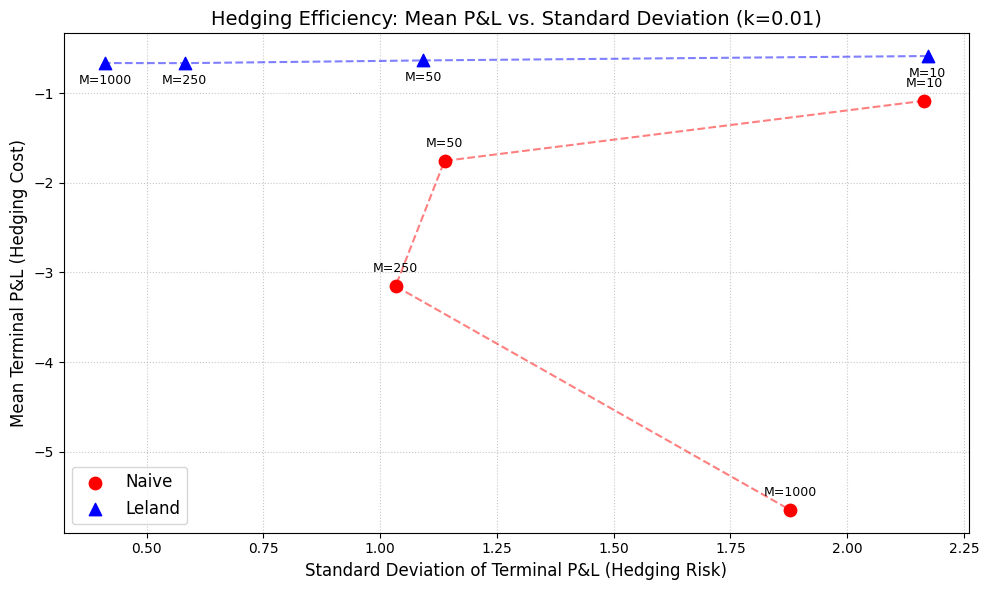

In [26]:
plt.figure(figsize=(10, 6))

# Plot performance curves
plt.plot(naive_stds, naive_means, 'r--', alpha=0.5)
plt.plot(leland_stds, leland_means, 'b--', alpha=0.5)

# Overlay data points
for i, M in enumerate(M_values):
    plt.scatter(naive_stds[i], naive_means[i], color='red', s=80, 
                label='Naive' if i==0 else "")
    plt.scatter(leland_stds[i], leland_means[i], color='blue', s=80, marker='^', 
                label='Leland' if i==0 else "")
    
    # Annotate points with corresponding M
    plt.annotate(f'M={M}', (naive_stds[i], naive_means[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
    plt.annotate(f'M={M}', (leland_stds[i], leland_means[i]), 
                 textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)

# Formatting
plt.title('Hedging Efficiency: Mean P&L vs. Standard Deviation (k=0.01)', fontsize=14)
plt.xlabel(r'Standard Deviation of Terminal P&L (Hedging Risk)', fontsize=12)
plt.ylabel(r'Mean Terminal P&L (Hedging Cost)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 4. Conclusion & Findings

The empirical results perfectly demonstrate the fundamental theorem established by Leland (1985):

1. **The Failure of Naive Hedging:** Under standard Black-Scholes assumptions, increasing the hedging frequency $M$ reduces the variance of the portfolio. However, when proportional transaction costs are introduced, the Naive strategy's expected costs explode toward negative infinity as $M \to \infty$. This is clearly visible as the red curve dives drastically downward.
2. **Leland's Efficiency:** By artificially inflating the volatility used to calculate the Delta and price the option, the Leland strategy flattens the Delta curve. This drastically reduces trading volume (and thus transaction costs) while mildly increasing the theoretical tracking error. 
3. **The Trade-off Curve:** The blue Leland curve dominates the red Naive curve. At $M=1000$, the Naive strategy suffers an expected loss of $\approx -5.65$ to achieve a risk level of $\approx 1.87$. In stark contrast, the Leland strategy achieves a strictly superior risk level ($\approx 0.41$) for a fraction of the cost ($\approx -0.66$).

By intentionally "mis-hedging," the bank successfully bounds its operational costs while maintaining tight control over the variance of the portfolio.